# Lasso Regression (L1 Regularization)

In Lasso Regression, we add a regularization term to the loss function.

---

## Loss Function (Lasso)

$$
L = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \lambda |w|
$$

---

## Comparison with Ridge Regression

### Ridge (L2):

$$
L = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \lambda w^2
$$

### Lasso (L1):

$$
L = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \lambda |w|
$$

---

## Key Difference

- Ridge regression → shrinks weights but does not make them exactly zero
- Lasso regression → can shrink some weights exactly to **zero**

---

## Why Lasso is Useful

- Performs **feature selection automatically**
- Removes irrelevant features by setting their coefficients to zero
- Produces sparse models

---

## Intuition

- Large \(\lambda\) → more coefficients become zero  
- Small \(\lambda\) → behaves like normal linear regression

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Lasso
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

[28.19655888]
-1.4669977724278058


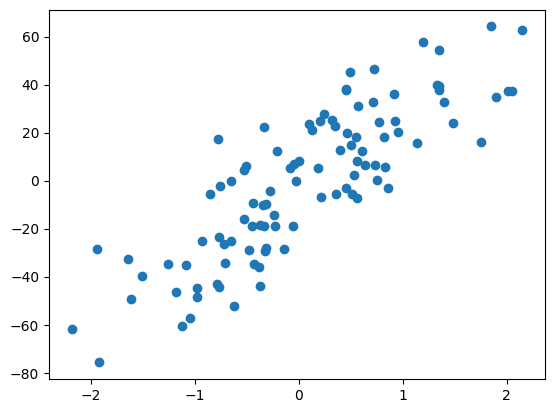

In [3]:
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

plt.scatter(X,y)

from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(X_train,y_train)
print(reg.coef_)
print(reg.intercept_)

c:\Users\LENOVO\Desktop\Fusemachines AI Fellowship 2026\venv\Lib\site-packages\sklearn\base.py:1336: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
c:\Users\LENOVO\Desktop\Fusemachines AI Fellowship 2026\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
c:\Users\LENOVO\Desktop\Fusemachines AI Fellowship 2026\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.128e+04, tolerance: 7.244e+00
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the so

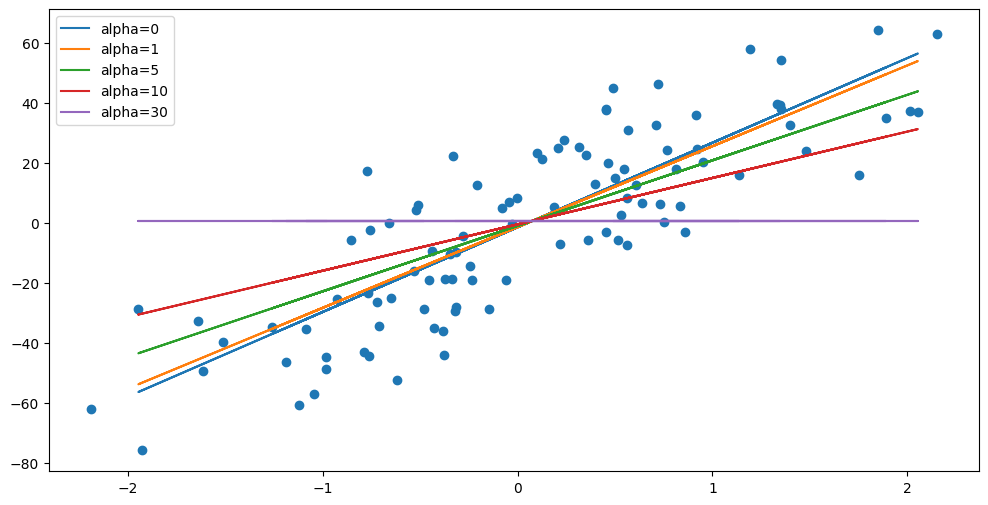

In [4]:
alphas = [0,1,5,10,30]
plt.figure(figsize=(12,6))
plt.scatter(X,y)
for i in alphas:
    L = Lasso(alpha=i)
    L.fit(X_train,y_train)
    plt.plot(X_test,L.predict(X_test),label='alpha={}'.format(i))
plt.legend()
plt.show()
    

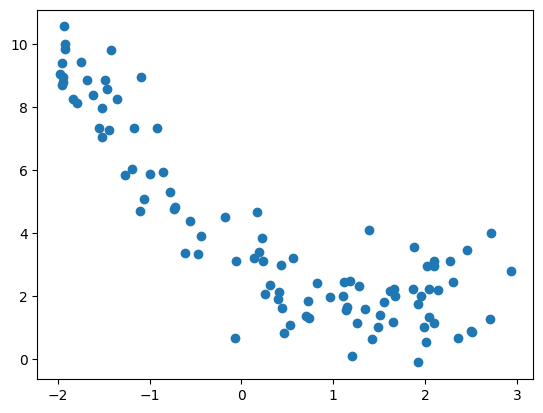

In [5]:
m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m, 1)

plt.scatter(x1, x2)
plt.show()

c:\Users\LENOVO\Desktop\Fusemachines AI Fellowship 2026\venv\Lib\site-packages\sklearn\base.py:1336: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
c:\Users\LENOVO\Desktop\Fusemachines AI Fellowship 2026\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
c:\Users\LENOVO\Desktop\Fusemachines AI Fellowship 2026\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.587e+01, tolerance: 8.523e-02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the so

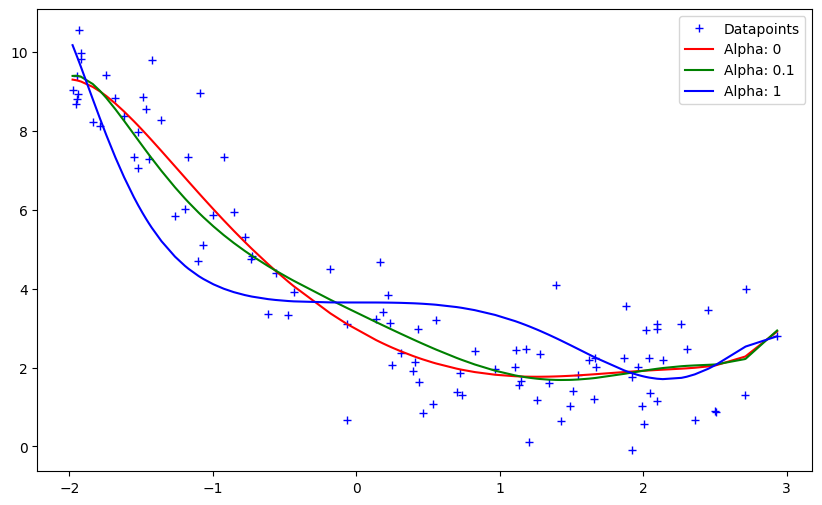

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

def get_preds_lasso(x1, x2, alpha):
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=16)),
        ('lasso', Lasso(alpha=alpha))
    ])
    model.fit(x1, x2)
    return model.predict(x1)

alphas = [0, 0.1, 1]
cs = ['r', 'g', 'b']

plt.figure(figsize=(10, 6))
plt.plot(x1, x2, 'b+', label='Datapoints')

for alpha, c in zip(alphas, cs):
    preds = get_preds_lasso(x1, x2, alpha)
    # Plot
    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:, 0])], c, label='Alpha: {}'.format(alpha))

plt.legend()
plt.show()

## Points on Lasso Regression

---

### 1. How are coefficients affected  
Lasso regression shrinks coefficients toward zero using L1 regularization.  
Some coefficients can become exactly zero, effectively removing those features.

---

### 2. Higher coefficients are affected more  
Features with larger weights are penalized more strongly.  
This encourages the model to reduce reliance on less important or noisy features.

---

### 3. Impact on bias and variance  
Lasso increases bias slightly but significantly reduces variance.  
This trade-off helps improve generalization and reduces overfitting.

---

### 4. Effect on loss function  
Lasso adds an absolute value penalty term to the loss function.  
This changes optimization behavior and makes the solution sparse.

## Why Lasso Regression Creates Sparsity

Lasso regression creates sparsity because it uses the L1 penalty, which is based on the absolute value of the coefficients. Unlike L2 regularization, the L1 penalty has a sharp corner at zero, which makes the optimization process more likely to push some weights exactly to zero rather than just shrinking them. Geometrically, the constraint region formed by L1 regularization has corners aligned with the axes, so the optimal solution often lands on these corners where some coefficients are exactly zero. As a result, Lasso naturally performs feature selection by keeping only the most important features and eliminating the rest.